# SLURM Data Exploration

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, mean_squared_error
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.impute import SimpleImputer 
from math import sqrt
import re
from sklearn.ensemble import RandomForestRegressor

# Load in Dataset and Column Types

In [20]:
# Loading the dataset
# Dropping unnamed columns
df = pd.read_csv('/mnt/research/CMSE495-SS24-ICER/slurm_usage/DID_FINAL_SLURM_OCT_2023.csv', header = 0, sep = "|", nrows = 1000000)
columns_to_drop = [0, 1]
df.drop(df.columns[columns_to_drop], axis = 1, inplace = True)
df

,JobID,User,Group,Submit,Start,End,Elapsed,State,Account,AssocID,...,CPUTimeRAW,ReqCPUS,AllocCPUS,ReqMem,MaxRSS,ReqNodes,NNodes,NodeList,ReqTRES,AllocTRES
0,31496544,user_679,group_121,2023-03-21T11:13:45,Unknown,Unknown,00:00:00,PENDING,account_017,assocID_489,...,0,28,0,21000M,NaN,1,1,None assigned,"billing=3192,cpu=28,gres/gpu=4,mem=21000M,node=1",NaN
1,31497932,user_679,group_121,2023-03-21T11:31:18,Unknown,Unknown,00:00:00,PENDING,account_017,assocID_489,...,0,28,0,21000M,NaN,1,1,None assigned,"billing=3192,cpu=28,gres/gpu=4,mem=21000M,node=1",NaN
2,31993628,user_105,group_114,2023-03-22T18:19:12,Unknown,Unknown,00:00:00,PENDING,account_017,assocID_661,...,0,12,0,150G,NaN,1,1,None assigned,"billing=23347,cpu=12,gres/gpu=8,mem=150G,node=1",NaN
3,39087660,user_652,group_054,2023-04-04T13:09:10,Unknown,Unknown,00:00:00,PENDING,account_017,assocID_557,...,0,640,0,20G,NaN,10,10,None assigned,"billing=3112,cpu=640,mem=20G,node=10",NaN
4,59062820,user_188,group_046,2023-05-08T09:58:20,2024-01-01T00:58:57,2024-01-01T00:59:06,00:00:09,COMPLETED,account_017,assocID_676,...,360,40,40,8G,NaN,1,1,skl-029,"billing=1245,cpu=40,mem=8G,node=1","billing=1245,cpu=40,mem=8G,node=1"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,92914316,user_258,group_010,2023-10-05T10:50:51,2023-10-05T10:50:51,2023-10-05T10:53:33,00:02:42,COMPLETED,account_012,assocID_393,...,162,1,1,NaN,1226228K,1,1,acm-015,NaN,"cpu=1,mem=505202M,node=1"
999996,92914316,user_258,group_010,2023-10-05T10:50:51,2023-10-05T10:50:51,2023-10-05T10:53:33,00:02:42,COMPLETED,account_012,assocID_393,...,162,1,1,NaN,0,1,1,acm-015,NaN,"billing=76790,cpu=1,mem=505202M,node=1"
999997,92914316,user_178,group_154,2023-10-05T10:39:56,2023-10-05T10:50:51,2023-10-05T10:53:33,00:02:42,COMPLETED,account_012,assocID_393,...,162,1,1,505202M,NaN,1,1,acm-000,"billing=76790,cpu=1,mem=505202M,node=1","billing=76790,cpu=1,mem=505202M,node=1"
999998,92914316,user_258,group_010,2023-10-05T10:50:51,2023-10-05T10:50:51,2023-10-05T10:53:33,00:02:42,COMPLETED,account_012,assocID_393,...,162,1,1,NaN,1223748K,1,1,acm-000,NaN,"cpu=1,mem=505202M,node=1"


In [3]:
# Data type for each column
df.dtypes

JobID          int64
User          object
Group         object
Submit        object
Start         object
End           object
Elapsed       object
State         object
Account       object
AssocID       object
Partition     object
Timelimit     object
UserCPU       object
SystemCPU     object
TotalCPU      object
CPUTime       object
CPUTimeRAW     int64
ReqCPUS        int64
AllocCPUS      int64
ReqMem        object
MaxRSS        object
ReqNodes       int64
NNodes         int64
NodeList      object
ReqTRES       object
AllocTRES     object
dtype: object

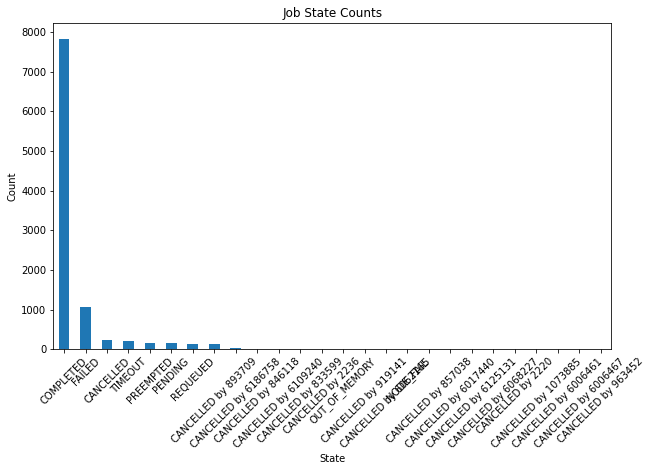

In [4]:
# Graph to show the count for each state
state_counts = df['State'].value_counts()

plt.figure(figsize=(10, 6))
state_counts.plot(kind='bar')
plt.title('Job State Counts')
plt.xlabel('State')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [5]:
df.isnull()

,JobID,User,Group,Submit,Start,End,Elapsed,State,Account,AssocID,...,CPUTimeRAW,ReqCPUS,AllocCPUS,ReqMem,MaxRSS,ReqNodes,NNodes,NodeList,ReqTRES,AllocTRES
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,True,False
9996,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
9997,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,True,False
9998,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,True,False


# KNN Model

In [6]:
# convert submit and start columns to datetime
df['Submit'] = pd.to_datetime(df['Submit'], errors='coerce')
df['Start'] = pd.to_datetime(df['Start'], errors='coerce')

In [7]:
# calculate target variable (queue time in seconds)
df['QueueTime'] = (df['Start'] - df['Submit']).dt.total_seconds()

In [8]:
df = df.dropna(subset=['QueueTime'])
df

,JobID,User,Group,Submit,Start,End,Elapsed,State,Account,AssocID,...,ReqCPUS,AllocCPUS,ReqMem,MaxRSS,ReqNodes,NNodes,NodeList,ReqTRES,AllocTRES,QueueTime
4,59062820,user_188,group_046,2023-05-08 09:58:20,2024-01-01 00:58:57,2024-01-01T00:59:06,00:00:09,COMPLETED,account_017,assocID_676,...,40,40,8G,NaN,1,1,skl-029,"billing=1245,cpu=40,mem=8G,node=1","billing=1245,cpu=40,mem=8G,node=1",20530837.0
5,59062828,user_188,group_046,2023-05-08 09:58:20,2024-01-01 01:00:49,2024-01-01T01:00:55,00:00:06,COMPLETED,account_017,assocID_676,...,40,40,8G,NaN,1,1,skl-029,"billing=1245,cpu=40,mem=8G,node=1","billing=1245,cpu=40,mem=8G,node=1",20530949.0
6,59062836,user_188,group_046,2023-05-08 09:58:20,2024-01-01 01:00:49,2024-01-01T01:00:55,00:00:06,COMPLETED,account_017,assocID_676,...,40,40,8G,NaN,1,1,skl-030,"billing=1245,cpu=40,mem=8G,node=1","billing=1245,cpu=40,mem=8G,node=1",20530949.0
7,59062844,user_188,group_046,2023-05-08 09:58:21,2024-01-01 00:58:57,2024-01-01T00:59:06,00:00:09,COMPLETED,account_017,assocID_676,...,40,40,8G,NaN,1,1,amr-207,"billing=1245,cpu=40,mem=8G,node=1","billing=1245,cpu=40,mem=8G,node=1",20530836.0
8,59062852,user_188,group_046,2023-05-08 09:58:21,2024-01-01 00:58:57,2024-01-01T00:59:06,00:00:09,COMPLETED,account_017,assocID_676,...,40,40,8G,NaN,1,1,amr-207,"billing=1245,cpu=40,mem=8G,node=1","billing=1245,cpu=40,mem=8G,node=1",20530836.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,91654664,user_258,group_010,2023-09-30 21:27:31,2023-09-30 21:27:31,2023-10-01T13:27:44,16:00:13,FAILED,account_080,assocID_308,...,25,25,NaN,8339036K,5,5,"amr-[189,191,210,217,246]",NaN,"cpu=25,mem=1250G,node=5",0.0
9996,91654744,user_646,group_080,2023-09-30 15:33:45,2023-09-30 19:21:55,2023-10-03T07:22:13,2-12:00:18,TIMEOUT,account_080,assocID_308,...,50,50,2500G,NaN,1,10,"acm-[019-020,032,036,038,041,047],amr-[200,219...","billing=389120,cpu=50,mem=2500G,node=1","billing=389120,cpu=50,mem=2500G,node=10",13690.0
9997,91654744,user_258,group_010,2023-09-30 19:21:55,2023-09-30 19:21:55,2023-10-03T07:22:19,2-12:00:24,CANCELLED,account_080,assocID_308,...,5,5,NaN,7252K,1,1,acm-019,NaN,"cpu=5,mem=250G,node=1",0.0
9998,91654744,user_258,group_010,2023-09-30 19:21:55,2023-09-30 19:21:55,2023-10-03T07:22:19,2-12:00:24,COMPLETED,account_080,assocID_308,...,50,50,NaN,0,10,10,"acm-[019-020,032,036,038,041,047],amr-[200,219...",NaN,"billing=389120,cpu=50,mem=2500G,node=10",0.0


In [9]:
# encode categorical variables
data_encoded = pd.get_dummies(df, columns=['User', 'Group', 'State', 'Account', 'AssocID', 'Partition'])

In [10]:
# normalize numerical variables
scaler = StandardScaler()
numerical_features = ['ReqCPUS', 'AllocCPUS']  # Add more numerical features here
data_encoded[numerical_features] = scaler.fit_transform(data_encoded[numerical_features])

/opt/software/Python/3.6.4-foss-2018a/lib/python3.6/site-packages/sklearn/preprocessing/data.py:617: DataConversionWarning: Data with input dtype int64 were all converted to float64 by StandardScaler.
  return self.partial_fit(X, y)
/opt/software/Python/3.6.4-foss-2018a/lib/python3.6/site-packages/sklearn/base.py:462: DataConversionWarning: Data with input dtype int64 were all converted to float64 by StandardScaler.
  return self.fit(X, **fit_params).transform(X)


In [11]:
# Feature Engineering
# create new features from 'Submit' and 'Start' columns
data_encoded['Submit_weekday'] = data_encoded['Submit'].dt.weekday
data_encoded['Submit_hour'] = data_encoded['Submit'].dt.hour

In [12]:
# Split the Data
X = data_encoded.drop(['QueueTime', 'Submit', 'Start', 'End'], axis=1)  # Drop non-feature columns
y = data_encoded['QueueTime']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
def convert_to_seconds(time_str):
    if pd.isnull(time_str) or not isinstance(time_str, str):
        return None  # Handle non-string inputs
    parts = time_str.split('-')
    if len(parts) == 2:
        days, time = parts
        hours, minutes, seconds = map(int, time.split(':'))
        return int(days) * 86400 + hours * 3600 + minutes * 60 + seconds
    else:
        hours, minutes, seconds = map(int, parts[0].split(':'))
        return hours * 3600 + minutes * 60 + seconds

# Apply the conversion function
df['Elapsed'] = df['Elapsed'].apply(convert_to_seconds)

# Verify conversion and handle non-numeric values
print(df['Elapsed'].head())
df['Elapsed'].fillna(0, inplace=True)  # Example handling strategy: replace NaNs with 0

# Now 'Elapsed' is ready for use in model training

4    9
5    6
6    6
7    9
8    9
Name: Elapsed, dtype: int64


/opt/software/Python/3.6.4-foss-2018a/lib/python3.6/site-packages/ipykernel_launcher.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  
/opt/software/Python/3.6.4-foss-2018a/lib/python3.6/site-packages/pandas/core/series.py:4536: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  downcast=downcast,
